**🌐 Language:** **English** | [한국어 →](./why_causal_inference_ko.ipynb)

# Why Should We Care About Causal Inference?


Causal inference asks us to answer "what if" questions, which are often called counterfactuals.

Suppose you are thinking about education policy. If the budget is limited, should you give tablets to every student? Or should you build a library instead?

At the core of that question is a causal question.

These kinds of causal questions appear everywhere in everyday life. Does more education really raise income? Does increasing cigarette prices reduce smoking rates? Will a new advertising campaign actually increase sales?

No matter what field you work in, you will eventually run into questions like these.

The problem is that answering them is much harder than it first appears. We are all familiar with the phrase "correlation is not causation," but it is not always easy to explain clearly why that is true.


## 1) Counterfactuals and Potential Outcomes: The Starting Point of Causal Effects


Intuitively, it is not too hard to understand why association is not the same as causation.

Imagine that schools with tablets tend to have higher test scores. But if the schools that adopted tablets already had better funding, more after-school support, and stronger teachers, their students might have performed above average even without tablets.

So we cannot conclude that "tablets improve academic achievement." All we can say is that tablets and higher academic performance are associated with each other.


In [9]:
import pandas as pd
import numpy as np
from scipy.special import expit
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style

style.use("fivethirtyeight")

np.random.seed(123)
n = 100
tuition = np.random.normal(1000, 300, n).round()
tablet = np.random.binomial(1, expit((tuition - tuition.mean()) / tuition.std())).astype(bool)
enem_score = np.random.normal(200 - 50 * tablet + 0.7 * tuition, 200)
enem_score = (enem_score - enem_score.min()) / enem_score.max()
enem_score *= 1000

data = pd.DataFrame(dict(enem_score=enem_score, Tuition=tuition, Tablet=tablet))

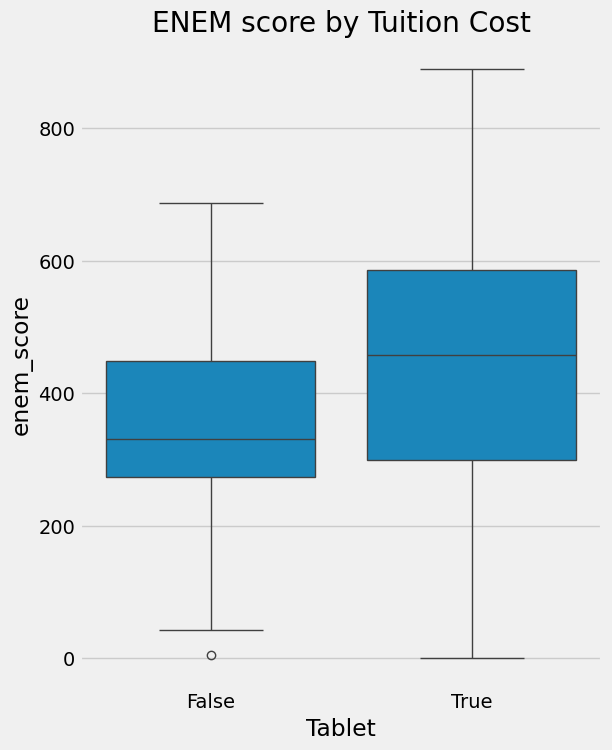

In [10]:
plt.figure(figsize=(6,8))
sns.boxplot(y="enem_score", x="Tablet", data = data).set_title('ENEM score by Tuition Cost')
plt.show()

Going beyond intuition, let us now define the notation more carefully. This will be the common language we use throughout the rest of causal inference, so it is worth getting comfortable with it.

$T_i$ indicates whether unit $i$ received the treatment.

$$
T_i=\begin{cases}
1 & \text{: unit } i \text{ receives the treatment}\\
0 & \text{: unit } i \text{ does not receive the treatment}
\end{cases}
$$

Here, treatment means the intervention whose effect we want to understand. In the example above, giving tablets to students is the treatment.

Next, let $Y_i$ denote the observed outcome variable for unit $i$. The central question of causal inference is: "Does the treatment affect this outcome?" In our example, academic performance is the outcome variable.

But now we run into a fundamental problem.

We cannot observe the same student in both a world where they received a tablet and a world where they did not. Only one of those realities can exist. This is the core reason causal inference is hard.
To handle this problem rigorously, we use the idea of potential outcomes.

- $Y_{0i}$: the potential outcome for unit $i$ if it did not receive the treatment
- $Y_{1i}$: the potential outcome for unit $i$ if it did receive the treatment

Both are possible outcomes, but in reality we can observe only one of them. For example, if student $i = 1$ received a tablet, we can observe $Y_{11}$, but not $Y_{01}$.

The outcome that actually happened is called the factual outcome, and the outcome from the unrealized alternative is called the counterfactual outcome.

Based on this idea, we can define the individual treatment effect (ITE).

$$ITE_i = Y_{1i} - Y_{0i}$$

This is the difference between the outcome with treatment and the outcome without treatment for a single person: in other words, "How much did the treatment matter for this person?" It is conceptually clear, but because we cannot observe the counterfactual, we cannot compute the ITE directly.

That is why, in practice, we often work with the average treatment effect (ATE).

$$ATE = E[Y_1 - Y_0]$$

$E[\cdots]$ denotes an expectation, or average. The ATE asks, "What is the average effect of the treatment in the full population?"

We can also look at how effective the treatment was specifically for those who actually received it. This is the average treatment effect on the treated (ATT).

$$ATT = E[Y_1 - Y_0 \mid T=1]$$


To build intuition, suppose we had the power to travel across the multiverse and observe counterfactuals directly.

With that power, we could collect data from four schools and know both whether each student received a tablet and what their annual academic test score would be.
Here, receiving a tablet is the treatment ($T=1$), and $Y$ is academic achievement measured by test scores.
In that case, we could compare each unit's $Y_1$ and $Y_0$ directly, so computing $ATE$ and $ATT$ would be straightforward.


In [11]:
pd.DataFrame(dict(
    i= [1,2,3,4],
    y0=[500,600,800,700],
    y1=[450,600,600,750],
    t= [0,0,1,1],
    y= [500,600,600,750],
    ite=[-50,0,-200,50],
))

,i,y0,y1,t,y,ite
0,1,500,450,0,500,-50
1,2,600,600,0,600,0
2,3,800,600,1,600,-200
3,4,700,750,1,750,50


Here, the $ATE$ is the average of the last column, that is, the average of the individual treatment effects (ITE).

$ATE=(-50 + 0 - 200 + 50)/4 = -50$

This means that, on average, giving tablets lowered students' academic performance by 50 points.

The $ATT$ is the average of the $ITE$ values among the treated schools only ($T=1$).

$ATT=(- 200 + 50)/2 = -75$

So among the schools that actually received tablets, tablets lowered academic performance by 75 points on average.


The only reason we were able to do that calculation was that our imaginary multiverse ability gave us access to the counterfactual data as well. In reality, things look like this.


In [4]:
pd.DataFrame(dict(
    i= [1,2,3,4],
    y0=[500,600,np.nan,np.nan],
    y1=[np.nan,np.nan,600,750],
    t= [0,0,1,1],
    y= [500,600,600,750],
    te=[np.nan,np.nan,np.nan,np.nan],
))

,i,y0,y1,t,y,te
0,1,500.0,NaN,0,500,NaN
1,2,600.0,NaN,0,600,NaN
2,3,NaN,600.0,1,600,NaN
3,4,NaN,750.0,1,750,NaN


The treated group's $Y_0$ and the untreated group's $Y_1$ are never observed. Since we cannot compute the ITE, we also cannot directly obtain the ATE or the ATT.

At this point, you might think:

> "Why not just subtract the mean of the control group from the mean of the treated group?"

$ATE=(600+750)/2 - (500 + 600)/2 = 125$

That does not work. Compare it with the true $ATE = -50$ we computed earlier. Even the sign is reversed. A simple difference in means suggests a positive effect, but the true effect was negative.

Interpreting an observed association as if it were a causal effect is one of the most common and most damaging mistakes in causal inference. Why does this happen?


## 2) Why Might an Observed Mean Difference Fail to Be a Causal Effect?


The key is that a simple difference in means mixes together the causal effect and bias. Let us return to the tablet example.

If someone says, "Schools that provide tablets also have higher test scores," you can push back like this: "Those schools probably would have scored well even without tablets. They have stronger finances, can hire better teachers, and offer better facilities." In other words, the two groups were not comparable to begin with.

In the language of potential outcomes, this means that $E[Y_0|T=1] > E[Y_0|T=0]$: even without treatment, the treated group would have had better outcomes than the comparison group.

Now let us write this out more formally. The association we can compute from observed data is

$$E[Y|T=1] - E[Y|T=0] = E[Y_1|T=1] - E[Y_0|T=0]$$

If we add and subtract $E[Y_0|T=1]$, we can rewrite it as

$$E[Y|T=1] - E[Y|T=0] = \underbrace{E[Y_1 - Y_0|T=1]}_{ATT} + \underbrace{\{E[Y_0|T=1] - E[Y_0|T=0]\}}_{\text{Bias}}$$

So a simple mean difference equals the causal effect (ATT) plus bias.

Bias captures how different the two groups would be even in the absence of treatment. Besides tablet adoption, many other factors such as school finances, location, and teacher quality can affect both treatment assignment and outcomes. Variables that affect both treatment and outcome in this way are called confounders.

Ultimately, if we want to estimate the causal effect correctly, we need to remove this bias. That means the two groups must be similar on average in every respect other than the tablet treatment itself. This is the central challenge of causal inference.


Drawing this structure as a graph makes it easier to see where the bias comes from. In the figure below, `school finances / baseline resources` is a common cause of both tablet adoption and test scores, that is, a confounder.

The difference between schools that adopted tablets and those that did not therefore mixes together the effect of the tablets themselves and pre-existing differences in school resources.


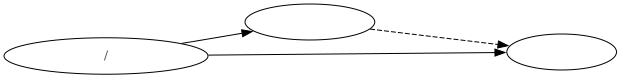

In [13]:
import graphviz as gr

g = gr.Digraph()
g.attr(rankdir="LR")
g.node("resources", "school finances / baseline resources")
g.node("tablet", "tablet adoption")
g.node("score", "test scores")

g.edge("resources", "tablet")
g.edge("resources", "score")
g.edge("tablet", "score", style="dashed", label="effect of interest")

g


## 3) Then When Does Association Become Causation?


Let us return to the decomposition we saw earlier.

$E[Y|T=1] - E[Y|T=0] = \underbrace{E[Y_1 - Y_0|T=1]}_{ATT} + \underbrace{\{E[Y_0|T=1] - E[Y_0|T=0]\}}_{\text{Bias}}$

For association to become causation, the bias term must be zero. That is, we need $E[Y_0|T=1] = E[Y_0|T=0]$. In words: "Even if the schools that received tablets had not received them, they would have performed similarly on average to the schools that did not receive tablets." The two groups must have been comparable from the start, except for tablet assignment.

When this condition holds, bias disappears and the simple mean difference becomes equal to the ATT.

If, in addition, the treated and untreated groups would respond similarly to treatment, meaning $E[Y_1 - Y_0|T=1] = E[Y_1 - Y_0|T=0]$, then the ATT equals the ATC (Average Treatment Effect on the Control), and the simple mean difference also becomes equal to the overall ATE.

$$E[Y|T=1] - E[Y|T=0] = ATT = ATC = ATE$$

Let us look at this visually. If we simply compare the average outcomes of two groups in observational data, we get the picture below.

![img](./assets/anatomy1.png)

The difference between the two groups mixes together two things. One is the effect of the tablets themselves. The other is factors such as school finances that make the two groups different even without treatment. That second part is bias.

The true treatment effect (ITE) can only be obtained by comparing, for the same unit, the outcome with treatment and the outcome without treatment. As the left panel below suggests, this would require observing the counterfactual as well.

![img](./assets/anatomy2.png)

The right panel visualizes bias. Even if everyone remained untreated so that only $Y_0$ exists, there is already a difference between the treated and comparison groups. That difference is bias, and it obscures the true treatment effect.

Now suppose tablets were assigned to schools at random. Then both wealthy and less wealthy schools would have the same chance of receiving tablets.

![img](./assets/anatomy3.png)

In that case, the difference between the two groups is explained entirely by the treatment effect. The bias disappears.

![img](./assets/anatomy4.png)

Even if we imagine only the untreated state, there is no difference between the two groups. We have created comparable groups.

Removing bias and making the two groups comparable is the central task of causal inference. So what is the most reliable way to do that in practice?


## 4) The Most Reliable Way to Reduce Bias: Randomized Experiments (RCTs)


The answer has already appeared in the discussion above: random assignment. If treatment is assigned at random, the entire distribution of potential outcomes becomes independent of treatment assignment.

$$(Y_0, Y_1) \perp T$$

Once this condition holds, the two conditions we discussed earlier follow automatically.

- $E[Y_0|T=1] = E[Y_0|T=0]$: bias disappears, and
- $E[Y_1|T=1] = E[Y_1|T=0]$: the two groups also respond similarly to treatment.

As a result, the treated and untreated groups become similar on average in every respect other than treatment status. In other words, the treatment and comparison groups become comparable, and the simple mean difference becomes the ATE.

$$E[Y\mid T=1] - E[Y\mid T=0] = ATT = ATC = ATE$$

That is why randomized controlled trials (RCTs) are considered the gold standard for estimating causal effects.


### 4-1) Example: An Online Classroom Experiment


Let us confirm this with real data. So far we have used the tablet example, but here we will use experimental data on the effect of online instruction on academic achievement.

In this experiment, university students were randomly assigned to one of three formats: face-to-face, online, or blended. Which format a student received was determined independently of the student's characteristics.
The treatment ($T$) is the class format, and the outcome variable ($Y$) is the final exam score.

What would go wrong if we compared these groups without random assignment? Students who choose online classes might already be especially self-directed learners, or they might instead be students with heavier work burdens who cannot commute easily. If those kinds of differences are mixed into the results, we cannot isolate the pure effect of class format. Random assignment removes this bias on average.


In [34]:
import pandas as pd
import numpy as np

data = pd.read_csv("./data/online_classroom.csv")
print(data.shape)
data.head()

(323, 10)


,gender,asian,black,hawaiian,hispanic,unknown,white,format_ol,format_blended,falsexam
0,0,0.0,0.0,0.0,0.0,0.0,1.0,0,0.0,63.29997
1,1,0.0,0.0,0.0,0.0,0.0,1.0,0,0.0,79.96000
2,1,0.0,0.0,0.0,0.0,0.0,1.0,0,1.0,83.37000
3,1,0.0,0.0,0.0,0.0,0.0,1.0,0,1.0,90.01994
4,1,0.0,0.0,0.0,0.0,0.0,1.0,1,0.0,83.30000


In [35]:
(data
 .assign(class_format = np.select(
     [data["format_ol"].astype(bool), data["format_blended"].astype(bool)],
     ["online", "blended"],
     default="face_to_face"
 ))
 .groupby(["class_format"])
 .mean())

,gender,asian,black,hawaiian,hispanic,unknown,white,format_ol,format_blended,falsexam
class_format,,,,,,,,,,
blended,0.550459,0.217949,0.102564,0.025641,0.012821,0.012821,0.628205,0.0,1.0,77.093731
face_to_face,0.633333,0.202020,0.070707,0.000000,0.010101,0.000000,0.717172,0.0,0.0,78.547485
online,0.542553,0.228571,0.028571,0.014286,0.028571,0.000000,0.700000,1.0,0.0,73.635263


Estimating the causal effect in an RCT is simple: we compare group means. The average score in face-to-face classes is 78.54, while the average score in online classes is 73.63, so the estimated ATE is about -4.91 points. In other words, online instruction lowers students' scores by roughly 5 points on average.

That is the whole idea. We do not need to worry about whether students in the online class were lower-income or whether they differed in baseline ability. Random assignment already removed that kind of bias at the design stage.

Of course, we should still verify that the randomization worked well in practice. It is good to check whether variables such as gender, race, and baseline achievement are balanced across groups. In this dataset, `gender`, `asian`, `hispanic`, and `white` look fairly similar across groups, but `black` differs somewhat. In a small sample, random assignment can still generate accidental imbalance like this, and those differences tend to shrink naturally as the sample gets larger.


### 4-2) Real-World Limits and the Assignment Mechanism

RCTs are simple and powerful, but they are not always feasible in practice. They may be too costly, ethically impossible, or difficult to control at the policy level. For example, if we want to know the effect of smoking during pregnancy on newborn birth weight, we obviously cannot randomly assign pregnant women to smoke.

Even so, whenever we face a causal question, we should first ask: "What would the ideal experiment look like?" That thought experiment becomes the benchmark for observational study design.

This is where the quasi-experimental methods we will study later become useful. They cannot directly guarantee $(Y_0, Y_1) \perp T$ the way an RCT can, but they try to make the two groups as comparable as possible by asking, "Which covariates would make treatment assignment look as if it were random?"

The more plausible that assumption is, the more convincing the causal interpretation becomes. The methods we will cover later, such as Matching, DiD, Synthetic Control, IV, and RDD, are all different attempts to satisfy that goal. Their techniques differ, but the objective is the same: how can we make the two groups comparable?


## References

This notebook was written with reference to Matheus Facure's Python Causality Handbook.

- [01 - Introduction To Causality](https://matheusfacure.github.io/python-causality-handbook/01-Introduction-To-Causality.html)
- [02 - Randomised Experiments](https://matheusfacure.github.io/python-causality-handbook/02-Randomised-Experiments.html)
- [04 - Graphical Causal Models](https://matheusfacure.github.io/python-causality-handbook/04-Graphical-Causal-Models.html)
